In [2]:
!pip install -U langchain langgraph langchain-openai langsmith pydantic


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install -U langchain langchain-ollama langsmith

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
print("Tracing:", os.getenv("LANGSMITH_TRACING"))
print("Project:", os.getenv("LANGSMITH_PROJECT1"))
print("API key loaded:", bool(os.getenv("LANGSMITH_API_KEY")))

Tracing: true
Project: ollama-test
API key loaded: True


In [5]:
from langchain_ollama import ChatOllama

# Create Ollama LLM
llm = ChatOllama(
    model="llama3.2",
    temperature=0
)

# Ask a question
question = "Explain Multi-Query RAG in simple words."

response = llm.invoke(question)

print("Answer:")
print(response.content)

Answer:
Multi-Query RAG (Rank Aggregation) is a technique used in search engines to rank search results for multiple queries at the same time.

Imagine you're searching for a new phone, and you also want to find the best restaurants in your area. A regular search engine would rank the phone results first and then the restaurant results separately.

Multi-Query RAG, on the other hand, combines the results of both queries into a single ranking. It looks at the relevance of each result to both queries and ranks them together.

For example, if a website has a phone review section and also mentions a nearby restaurant, it would be ranked higher in the combined results. This way, you get a more comprehensive view of the search results, and you can find what you're looking for more easily.

Multi-Query RAG is useful for search engines that need to handle multiple queries simultaneously, such as voice assistants or search engines that support multiple search queries at once.


In [6]:
from typing import TypedDict, Literal, Annotated
from typing_extensions import NotRequired

from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage,
    ToolMessage
)

from langchain_core.tools import tool

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

from langgraph.prebuilt import (
    ToolNode,
    tools_condition
)

In [7]:
@tool
def calculator(expression: str) -> str:
    """
    Calculate a mathematical expression.
    """

    try:
        result = eval(expression, {"__builtins__": {}}, {})
        return str(result)

    except Exception as e:
        return f"Error: {e}"

from datetime import datetime
@tool
def current_datetime() -> str:
    """
    Returns the current date and time.
    """

    now = datetime.now()

    return now.strftime("%Y-%m-%d %H:%M:%S")






@tool
def unit_converter(value: float, from_unit: str, to_unit: str) -> str:
    """
    Convert between common units of length, weight, and temperature.

    Examples:
    10 km to miles
    5 kg to pounds
    100 celsius to fahrenheit
    """

    # Length conversions → meters
    length_to_meter = {
        "m": 1,
        "km": 1000,
        "cm": 0.01,
        "mm": 0.001,
        "mile": 1609.344,
        "ft": 0.3048,
        "inch": 0.0254
    }

    # Weight conversions → kilograms
    weight_to_kg = {
        "kg": 1,
        "g": 0.001,
        "mg": 0.000001,
        "lb": 0.45359237,
        "ounce": 0.0283495
    }

    from_unit = from_unit.lower()
    to_unit = to_unit.lower()

    # Length
    if from_unit in length_to_meter and to_unit in length_to_meter:

        meters = value * length_to_meter[from_unit]
        result = meters / length_to_meter[to_unit]

        return f"{value} {from_unit} = {result:.4f} {to_unit}"

    # Weight
    if from_unit in weight_to_kg and to_unit in weight_to_kg:

        kg = value * weight_to_kg[from_unit]
        result = kg / weight_to_kg[to_unit]

        return f"{value} {from_unit} = {result:.4f} {to_unit}"

    # Celsius → Fahrenheit
    if from_unit in ["c", "celsius"] and to_unit in ["f", "fahrenheit"]:

        result = (value * 9 / 5) + 32

        return f"{value}°C = {result:.2f}°F"

    # Fahrenheit → Celsius
    if from_unit in ["f", "fahrenheit"] and to_unit in ["c", "celsius"]:

        result = (value - 32) * 5 / 9

        return f"{value}°F = {result:.2f}°C"

    return "Conversion not supported."





@tool
def text_counter(text: str) -> str:
    """
    Counts the number of characters, words, sentences, and lines
    in the provided text.
    """

    characters = len(text)
    characters_without_spaces = len(text.replace(" ", ""))
    words = len(text.split())
    lines = len(text.splitlines())

    # Simple sentence count
    sentences = sum(
        text.count(symbol)
        for symbol in [".", "!", "?"]
    )

    return (
        f"Characters: {characters}\n"
        f"Characters without spaces: {characters_without_spaces}\n"
        f"Words: {words}\n"
        f"Sentences: {sentences}\n"
        f"Lines: {lines}"
    )

#lookup tools
student_data = {
    "101": {
        "name": "Rahul",
        "course": "Computer Science",
        "year": 3,
        "marks": 85
    },
    "102": {
        "name": "Priya",
        "course": "Data Science",
        "year": 2,
        "marks": 91
    },
    "103": {
        "name": "Amit",
        "course": "Artificial Intelligence",
        "year": 4,
        "marks": 88
    }
}

@tool
def student_lookup(student_id: str) -> str:
    """
    Look up student information using the student ID.
    """

    student = student_data.get(student_id)

    if student is None:
        return f"No student found with ID {student_id}"

    return (
        f"Name: {student['name']}\n"
        f"Course: {student['course']}\n"
        f"Year: {student['year']}\n"
        f"Marks: {student['marks']}"
    )


In [8]:
from langchain.agents import create_agent
tools = [
    calculator,
    current_datetime,
    unit_converter,
    text_counter,
    student_lookup
]

llm_with_tools = llm.bind_tools(tools)


def agent_node(state:MessagesState):
    response = llm_with_tools.invoke(state["messages"])
    
    return {
        "messages" :[response]
    }




In [9]:
tool_node = ToolNode(tools)

In [10]:
builder = StateGraph(MessagesState)

builder.add_node("agent",agent_node)
builder.add_node("tools" , tool_node)

builder.add_edge(START,"agent")

builder.add_conditional_edges("agent" , tools_condition)
builder.add_edge("tools" , "agent")

simple_agent = builder.compile()

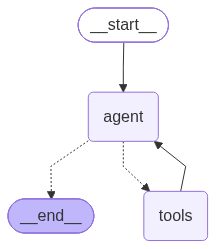

In [11]:
simple_agent

In [34]:
from langchain_core.messages import HumanMessage

result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="What is the current date and what is 250 * 20?"
        )
    ]
})


In [52]:
result

{'messages': [HumanMessage(content='What is the current date and what is 250 * 20?', additional_kwargs={}, response_metadata={}, id='362ac192-9fb3-4bf6-9359-4f96ce6f42c8'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-08-31T10:48:06.2572578Z', 'done': True, 'done_reason': 'stop', 'total_duration': 87959632300, 'load_duration': 56723781900, 'prompt_eval_count': 332, 'prompt_eval_duration': 23012825000, 'eval_count': 27, 'eval_duration': 6125719000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a0576d-9ca1-73f1-8604-8b4faa278a34-0', tool_calls=[{'name': 'current_datetime', 'args': {}, 'id': '4b698ddd-a729-4aed-b7cc-21a30d049169', 'type': 'tool_call'}, {'name': 'calculator', 'args': {'expression': '250 * 20'}, 'id': '86b48d33-7977-4694-9407-f232b44e230b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 332, 'output_tokens': 27, 'total_tokens': 359}),
  ToolMe

In [24]:
result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="what is langchain?"
        )
    ]
})

In [25]:
result

{'messages': [HumanMessage(content='what is langchain?', additional_kwargs={}, response_metadata={}, id='ece74ff9-d019-417a-967c-6fb7d1c4d1b0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-08-31T11:23:50.1226512Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4310279000, 'load_duration': 27915600, 'prompt_eval_count': 323, 'prompt_eval_duration': 631955000, 'eval_count': 18, 'eval_duration': 3537278000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a0578f-a10d-7a51-bdb3-a0f3325e4f0b-0', tool_calls=[{'name': 'text_counter', 'args': {'text': 'langchain'}, 'id': 'bfac77dc-a483-4529-b00d-905090b63b15', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 323, 'output_tokens': 18, 'total_tokens': 341}),
  ToolMessage(content='Characters: 9\nCharacters without spaces: 9\nWords: 1\nSentences: 0\nLines: 1', name='text_counter', id='51e5ebfc-4cbe-449f-9b8f-95

In [54]:


result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="Calculate 18% GST on ₹74,500."
        )
    ]
})

In [55]:
result

{'messages': [HumanMessage(content='Calculate 18% GST on ₹74,500.', additional_kwargs={}, response_metadata={}, id='f5944e01-2865-47ac-9eab-6e63627c4fba'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-08-31T10:56:06.983211Z', 'done': True, 'done_reason': 'stop', 'total_duration': 96034327600, 'load_duration': 60444640500, 'prompt_eval_count': 329, 'prompt_eval_duration': 22104031000, 'eval_count': 22, 'eval_duration': 4976469000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a05774-d9db-7011-884b-890ddcef4c79-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '18/100 * 74500'}, 'id': '0e3e8e18-f388-4361-8e22-c3e84d8b8c94', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 329, 'output_tokens': 22, 'total_tokens': 351}),
  ToolMessage(content='13410.0', name='calculator', id='bfd8149e-1671-4fbe-a5eb-114df7cb438a', tool_call_id='0e3e8e18-f388-4361-8

In [20]:


result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="Convert 10 km to miles."
        )
    ]
})

In [21]:
result

{'messages': [HumanMessage(content='Convert 10 km to miles.', additional_kwargs={}, response_metadata={}, id='026ac2ab-63b0-4fe5-9f8c-b115806223bf'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-08-31T11:16:52.2197802Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7390968000, 'load_duration': 21961100, 'prompt_eval_count': 325, 'prompt_eval_duration': 265281000, 'eval_count': 32, 'eval_duration': 6684032000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a05789-33ff-7cc1-a65a-f6d7e52d283f-0', tool_calls=[{'name': 'unit_converter', 'args': {'value': '10', 'from_unit': 'km', 'to_unit': 'miles'}, 'id': '60babe2b-9fb1-45f1-be7a-a31c0114d5b4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 325, 'output_tokens': 32, 'total_tokens': 357}),
  ToolMessage(content='Conversion not supported.', name='unit_converter', id='bf26090d-86c3-4cc1-b6af-09bc61509912

In [22]:
result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="what is Genai?"
        )
    ]
})

In [23]:
result

{'messages': [HumanMessage(content='what is Genai?', additional_kwargs={}, response_metadata={}, id='e33830e7-364c-4389-bab4-9f8277027f2a'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-08-31T11:22:23.0104475Z', 'done': True, 'done_reason': 'stop', 'total_duration': 41344189200, 'load_duration': 47224500, 'prompt_eval_count': 323, 'prompt_eval_duration': 23742860000, 'eval_count': 45, 'eval_duration': 16192788000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a0578d-bc0f-7d01-b00d-c4fd549158eb-0', tool_calls=[{'name': 'text_counter', 'args': {'text': 'Genai is an artificial intelligence (AI) platform developed by Google that uses natural language processing (NLP) to analyze and understand human language.'}, 'id': 'a2aae3f4-0de5-45c6-839e-d1f8b56968be', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 323, 'output_tokens': 45, 'total_tokens': 368}),
  ToolMe

In [35]:


result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="Convert 15 kilometers into miles."
        )
    ]
})

In [36]:
result

{'messages': [HumanMessage(content='Convert 15 kilometers into miles.', additional_kwargs={}, response_metadata={}, id='0fd643a5-0d37-4017-916f-4484bd41d14c'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-09-01T07:21:17.12148Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14351930900, 'load_duration': 220754200, 'prompt_eval_count': 325, 'prompt_eval_duration': 3997135000, 'eval_count': 31, 'eval_duration': 5447329000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a05bd7-c562-7cc2-b606-0494c594eeb6-0', tool_calls=[{'name': 'unit_converter', 'args': {'value': '15', 'from_unit': 'km', 'to_unit': 'mi'}, 'id': '6b34338c-7830-4a9f-91cc-5a99304817a8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 325, 'output_tokens': 31, 'total_tokens': 356}),
  ToolMessage(content='Conversion not supported.', name='unit_converter', id='88396fb1-f0ef-47ad-8487-67bc

In [37]:



result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="How many words are present in this paragraph?"
        )
    ]
})

In [38]:
result

{'messages': [HumanMessage(content='How many words are present in this paragraph?', additional_kwargs={}, response_metadata={}, id='bca3be54-2b5e-46fa-a6e0-500abafa1510'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-09-01T07:23:06.5818954Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7011464700, 'load_duration': 35584600, 'prompt_eval_count': 327, 'prompt_eval_duration': 2735687000, 'eval_count': 25, 'eval_duration': 3892386000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a05bd9-8e35-7173-9ca0-59579ef2ecf0-0', tool_calls=[{'name': 'text_counter', 'args': {'text': 'How many words are present in this paragraph?'}, 'id': 'cb22c67a-049b-4603-8c98-a0769b8ac275', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 327, 'output_tokens': 25, 'total_tokens': 352}),
  ToolMessage(content='Characters: 45\nCharacters without spaces: 38\nWords: 8\nSentences:

In [39]:


result = simple_agent.invoke({
    "messages": [
        HumanMessage(
            content="What will ₹50,000 become after adding 12%?"
        )
    ]
})

In [40]:
result

{'messages': [HumanMessage(content='What will ₹50,000 become after adding 12%?', additional_kwargs={}, response_metadata={}, id='93a06d38-6ff4-4e0d-a531-665dddd26900'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-09-01T08:12:40.1431353Z', 'done': True, 'done_reason': 'stop', 'total_duration': 79938737600, 'load_duration': 57578207700, 'prompt_eval_count': 331, 'prompt_eval_duration': 14210534000, 'eval_count': 32, 'eval_duration': 5136543000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--01a05c05-d097-73f3-81aa-61d70c816626-0', tool_calls=[{'name': 'unit_converter', 'args': {'from_unit': 'indian rupee', 'to_unit': 'amount with 12% increase', 'value': '50000'}, 'id': '7a023e0b-771d-4211-80f8-1b509ad60731', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 331, 'output_tokens': 32, 'total_tokens': 363}),
  ToolMessage(content='Conversion not supported.', name='

In [12]:
response = simple_agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "What course is student 102 studying and what are their marks?"
        }
    ]
})


print(response["messages"][-1].content)

Student 102, Priya, is studying Data Science and has a total of 91 marks.
